# 数据挖掘、机器学习算法实习生需求分析

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pyecharts
plt.style.use('ggplot')
%matplotlib inline
from pylab import mpl
mpl.rcParams['font.sans-serif'] = ['SimHei'] # sans-serif是无衬字体的意思，SimHei是一种无衬字体
plt.rc('figure',figsize = (10,10)) # 预设图片大小

## 导入数据

In [2]:
data_dm = pd.read_csv('datamining.csv')
data_ml = pd.read_csv('machinelearning.csv')
data_al = pd.read_csv('mlalgorithm.csv')
data = pd.concat([data_dm, data_ml, data_al], ignore_index = True)

## 数据预览和基本处理

In [3]:
data.sample(5) 

,auth_capital,city,com_class,com_fullname,com_id,com_intro,com_links,com_location,com_logo,com_name,...,job_deadline,job_detail,job_links,job_title,num_employee,released_time,tag,time_span,update_time,wage
839,注册资本：1000000万人民币,杭州,公司类型：有限责任公司（非自然人投资或控股的法人独资）,浙江菜鸟供应链管理有限公司,注册号：330184000210330,阿里巴巴旗下，全球智慧物流网络,https://www.shixiseng.com/com/com_43fam7c8lcuh,浙江省杭州市西湖区,https://sxsimg.xiaoyuanzhao.com/FF/7F/FFE5F9BE...,菜鸟网络,...,2018-04-30,"['1、本科以上学历、硕士博士优先。具有很强的逻辑分析能力，对数据敏感；\xa0', '2、...",https://www.shixiseng.com/intern/inn_ewafp06dgq5z,算法工程师,2000人以上,1周前,算法,2个月,2018-03-09 14:28:11,400-800/天
559,注册资本：1161万元人民币,北京,公司类型：有限责任公司(自然人投资或控股),深思考人工智能机器人科技（北京）有限公司,注册号：110108019692870,深思考ideepwise，有温情的人工智能,https://www.shixiseng.com/com/com_noporbzg01xe,北京市海淀区上地信息路12号中关村发展大厦B201-205室,https://sxsimg.xiaoyuanzhao.com/E5/20/E5860F5A...,深思考Ideepwise,...,2018-04-02,"['岗位职责:', '负责计算机视觉、深度学习相关的产品研发；', '负责计算机视觉算法的技...",https://www.shixiseng.com/intern/inn_ddksqil1xgjg,计算机视觉算法工程师,50-150人,46小时前,软件,3个月,2018-03-20 18:00:51,300-400/天
329,注册资本：20000万,广州,公司类型：有限责任公司(法人独资),广州虎牙信息科技有限公司,注册号：440126000724879,已获A轮融资的中国领先的互动内容提供商,https://www.shixiseng.com/com/com_xerxx57t205q,广州市番禺区南村镇万博二路79号万达商业广场北区B-1栋,https://sxsimg.xiaoyuanzhao.com/56/84/56730541...,虎牙信息,...,2020-12-31,"['1、负责虎牙直播的机器学习内容识别工作；', '2、负责目标检测、分割、识别的算法研发、...",https://www.shixiseng.com/intern/inn_pzmetlm8anar,（2018届春招）机器学习算法工程师实习生,500-2000人,3周前,算法,7个月,2018-02-26 10:52:07,580-860/天
942,注册资本：11224.4898万元人民币,北京,公司类型：其他有限责任公司,北京图为先科技有限公司,注册号：110108007867392,国内领先的地图导航及车联网服务提供商,https://www.shixiseng.com/com/com_9nlmwqg9tb48,北京市海淀区丰豪东路四维图新大厦A座,https://sxsimg.xiaoyuanzhao.com/06/D6/061879FF...,图吧,...,2018-06-30,"['职责：', '1、\r\n导航核心技术算法的研究和优化，路线规划、地图渲染、语音引导、全...",https://www.shixiseng.com/intern/inn_gpavsqf4qe3r,C/C++核心算法研发工程师,500-2000人,1月前,C/C++,7个月,2018-01-22 10:15:09,180-220/天
932,注册资本：204.0816万元人民币,北京,公司类型：有限责任公司(自然人投资或控股),远形时空科技（北京）有限公司,注册号：110108021152417,一家视觉SLAM技术公司,https://www.shixiseng.com/com/com_ppg3tltocikm,北京市海淀区王庄路清华同方科技广场D座705室,https://sxsimg.xiaoyuanzhao.com/61/65/61AA24A7...,远形时空,...,2018-04-01,NaN,https://www.shixiseng.com/intern/inn_pgolvwyffmwv,SLAM/图像算法工程师实习生,少于15人,1月前,算法,7个月,2018-01-29 10:44:41,200-300/天


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 978 entries, 0 to 977
Data columns (total 27 columns):
auth_capital      906 non-null object
city              974 non-null object
com_class         954 non-null object
com_fullname      974 non-null object
com_id            906 non-null object
com_intro         974 non-null object
com_links         978 non-null object
com_location      978 non-null object
com_logo          974 non-null object
com_name          974 non-null object
com_website       865 non-null object
com_welfare       978 non-null object
day_per_week      978 non-null object
detailed_intro    912 non-null object
est_date          906 non-null object
industry          960 non-null object
job_academic      978 non-null object
job_deadline      978 non-null object
job_detail        681 non-null object
job_links         978 non-null object
job_title         978 non-null object
num_employee      972 non-null object
released_time     978 non-null object
tag               978

In [5]:
data.loc[123] #随便看一个

auth_capital                                          注册资本：1200万人民币
city                                                             北京
com_class                                             公司类型：其他有限责任公司
com_fullname                                     融慧金科金融服务外包（北京）有限公司
com_id                                            组织机构代码：MA004WFN-X
com_intro                                 为金融机构提供智慧决策和系统解决方案的金融科技公司
com_links            https://www.shixiseng.com/com/com_k0d5xtvytr35
com_location                                   北京市朝阳区西大望路3号蓝堡国际中心1座
com_logo          https://sxsimg.xiaoyuanzhao.com/97/2F/970EEC7D...
com_name                                                       融慧金科
com_website                                   http://fintell.com.cn
com_welfare           ['工作氛围极好', '零食提供', '年轻群体', '良好团队氛围', '能学到很多']
day_per_week                                                   4天/周
detailed_intro    融慧金科，取意“通过科技，让金融更智慧”，是一家运用移动互联网大数据、人工智能技术和专业化风...
est_date                                        

In [6]:
# 丢掉重复的
data.drop_duplicates(subset = 'job_links', inplace = True)
data.shape

(878, 27)

通过上面的数据预览，可以发现有些缺失值，而且所有的数据都是object，需要处理

# 数据处理

创立新数据框

In [7]:
data_clean = data.drop(['com_id','com_links','com_website',
                       'com_welfare','detailed_intro','job_detail'],axis = 1)

## 处理auth_capital(处理不规整且需提取数字和转换字符串)

先处理auth_capital.处理前先看看数据类型

In [8]:
data.auth_capital.sample(10) 

610      注册资本：5000 万元
709               NaN
915    注册资本：1000万元人民币
129     注册资本：270万元人民币
473     注册资本：8000万元美元
715     注册资本：5000万人民币
599               NaN
471     注册资本：10 万元人民币
860      注册资本：1000 万元
912        注册资本：100万元
Name: auth_capital, dtype: object

使用split分割注册资本和数字

In [9]:
auth_capital = data['auth_capital'].str.split('：',expand = True)
auth_capital.sample(5)


,0,1
418,注册资本,87.2629万人民币
630,注册资本,9449万元美元
919,注册资本,117.650000万人民币
677,注册资本,124257.6745 万人民币
956,NaN,NaN


把数字提取出来

In [10]:
auth_capital['num'] = auth_capital[1].str.extract('([0-9.]+)',expand = False).astype('float')
auth_capital.sample(5)

,0,1,num
753,注册资本,100万人民币,100.0
471,注册资本,10 万元人民币,10.0
302,注册资本,3000 万元,3000.0
165,注册资本,5500 万元,5500.0
400,注册资本,1000万人民币,1000.0


看一下有什么单位

In [11]:
auth_capital[1].str.split('万',expand = True)[1].unique()

array(['美元', '人民币', '元美元', nan, '元人民币', '人民币元', '元', None, '元 人民币', '',
       '元 美元', '元港元（港币）', '港币', '香港元', '欧元', '元 港元（港币）'], dtype=object)

构造个函数，把单位转换成汇率，再把汇率和钱乘起来，得到工资
这里特别注意，如果一定要先把Nan转换成None再用这个函数，否则无法执行改函数。

In [12]:
def get_ex_rate(string):
    if string == None:
        return np.nan
    elif '人民币' in string:
        return 1.00
    elif '港' in string:
        return 0.80
    elif '美元' in string:
        return 6.29
    elif '欧元' in string:
        return 7.73
    elif '万' in string:
        return 1.00
    else:
        return np.nan



auth_capital.loc[auth_capital[1].isna(), 1] = None
sum(auth_capital[1].isna())
auth_capital['ex_rate'] = auth_capital[1].apply(get_ex_rate)
auth_capital['ex_rate'].unique()

array([6.29, 1.  ,  nan, 0.8 , 7.73])

得到真正的工资

In [13]:
data_clean['auth_capital'] = auth_capital['num'] * auth_capital['ex_rate']
data_clean['auth_capital'].head()

0    235875.0000
1     27570.9972
2       314.5000
3     28430.8000
4     28430.8000
Name: auth_capital, dtype: float64

## 处理day_per_week

先看看数据特征(有多少种工作制度)

In [14]:
data.day_per_week.unique()

array(['4天/周', '5天/周', '3天/周', '2天/周', '6天/周'], dtype=object)

同样地，把它们转换成数字类型

In [15]:
def get_day(string):
    if string == None:
        return np.nan
    elif '4' in string:
        return 4
    elif '5' in string:
        return 5
    elif '3' in string:
        return 3
    elif '2' in string:
        return 2
    elif '6' in string:
        return 6
    else:
        return np.nan
data_clean['day_per_week'] = data['day_per_week'][:].apply(get_day)
data_clean['day_per_week'].head()



0    4
1    5
2    4
3    4
4    4
Name: day_per_week, dtype: int64

## 处理num_employee

现在来处理公司规模。先看看数据特征

In [16]:
data.num_employee.unique()

array(['2000人以上', '500-2000人', nan, '50-150人', '15-50人', '150-500人',
       '少于15人', '5000人以上'], dtype=object)

把string转换成数字类型。也可以用函数。不过现在用一用普通方法。

In [17]:
# 注意loc()的用法：行是数字，所以可以用数字索引。但是列是str，所以要用str索引。
data_clean.loc[data['num_employee'] == '少于15人', 'num_employee'] = '小型企业'
data_clean.loc[data['num_employee'] == '15-50人', 'num_employee'] = '小型企业'
data_clean.loc[data['num_employee'] == '50-150人', 'num_employee'] = '小型企业'
data_clean.loc[data['num_employee'] == '150-500人', 'num_employee'] = '中型企业'
data_clean.loc[data['num_employee'] == '500-2000人', 'num_employee'] = '中型企业'
data_clean.loc[data['num_employee'] == '2000人以上', 'num_employee'] = '大型企业'
data_clean.loc[data['num_employee'] == '5000人以上', 'num_employee'] = '大型企业'
data_clean.loc[data['num_employee'].isna(), 'num_employee'] = np.nan
sum(data_clean['num_employee'].isna())
data_clean['num_employee'].sample(5)

621    大型企业
91     大型企业
246    小型企业
550    大型企业
836    小型企业
Name: num_employee, dtype: object

## 处理time_span

先看看有多少类型

In [18]:
data.time_span.unique()

array(['3个月', '4个月', '6个月', '7个月', '5个月', '9个月', '8个月', '10个月', '12个月',
       '13个月', '18个月', '14个月', '16个月', '11个月', '15个月', '2个月', '17个月',
       '1个月'], dtype=object)

可以看到，类型太多，虽然比较规整，但是赋值的速度会很慢。因此可以构造词典并mapping来替换str

In [19]:
# 对于字典，可以用dict['key_name'] = value的方式来构造
mapping = {}
for i in range(1,19):
    mapping[str(i) + '个月'] = i
print(mapping)

{'1个月': 1, '2个月': 2, '3个月': 3, '4个月': 4, '5个月': 5, '6个月': 6, '7个月': 7, '8个月': 8, '9个月': 9, '10个月': 10, '11个月': 11, '12个月': 12, '13个月': 13, '14个月': 14, '15个月': 15, '16个月': 16, '17个月': 17, '18个月': 18}


In [20]:
data_clean['time_span'] = data['time_span'].map(mapping)
data_clean.head(3)

,auth_capital,city,com_class,com_fullname,com_intro,com_location,com_logo,com_name,day_per_week,est_date,...,job_academic,job_deadline,job_links,job_title,num_employee,released_time,tag,time_span,update_time,wage
0,235875.0000,北京,公司类型：有限责任公司(台港澳法人独资),淘宝（中国）软件有限公司,淘宝网是亚太地区较大的网络零售、商圈,"杭州,北京",https://sxsimg.xiaoyuanzhao.com/FB/BC/FBDB6AC6...,淘宝,4,成立日期：2004-12-07,...,硕士,2018-04-13,https://www.shixiseng.com/intern/inn_g2vpcs8lukcr,【淘宝】算法工程师/算法专家,大型企业,7分钟前,数据挖掘,3,2018-03-21 10:48:06,200-201/天
1,27570.9972,上海,公司类型：股份有限公司(上市),游族网络股份有限公司,全球领先的互动娱乐供应商,上海市徐汇区宜山路711号游族大厦,https://sxsimg.xiaoyuanzhao.com/BD/6D/BD305709...,游族网络,5,成立日期：1995-09-22,...,本科,2020-12-31,https://www.shixiseng.com/intern/inn_46watgzrvqsg,大数据挖掘工程师 （2018校园）,中型企业,18分钟前,软件,4,2018-03-21 10:37:22,160-280/天
2,314.5000,广州,公司类型：有限责任公司(台港澳法人独资),广州网易互动娱乐有限公司,国内中国领先的互联网技术公司，游戏行业领导者。,杭州市滨江区网商路599号,https://sxsimg.xiaoyuanzhao.com/company_logo/2...,网易游戏,4,成立日期：2002-10-15,...,本科,2018-03-31,https://www.shixiseng.com/intern/inn_wnfrd8o7wly2,数据挖掘研究实习生（AI方向）,大型企业,32分钟前,数据挖掘,4,2018-03-21 10:23:45,130-150/天


## 处理wage(不规整且需要提取数字)

In [21]:
data.wage.sample

<bound method NDFrame.sample of 0      200-201/天
1      160-280/天
2      130-150/天
3      150-200/天
4      150-200/天
         ...    
972    180-300/天
973    200-300/天
974    100-120/天
976    150-300/天
977    200-300/天
Name: wage, Length: 878, dtype: object>

In [22]:
data['wage'].str.extract('([0-9]+)-([0-9]+)/天',expand = True)[0][1]
# 可以看到提取出来的是str。因此要先把它变成int再mean
data_clean['average_wage'] = data['wage'].str.extract('([0-9]+)-([0-9]+)/天',expand = True).astype(int).mean(axis=1)
data_clean['average_wage'].head()
# 需要特别注意的是，mean(axis=1)是求每一列的均值。

0    200.5
1    220.0
2    140.0
3    175.0
4    175.0
Name: average_wage, dtype: float64

## 处理est_data(处理时间型数据)

In [23]:
data['est_date'].sample(5)

75    成立日期：2003-01-21
44    成立日期：2013-10-14
56    成立日期：1997-09-25
22    成立日期：2015-11-17
45    成立日期：2007-10-16
Name: est_date, dtype: object

用pd.to_datetime()来转换数据

In [24]:
# 特别注意，to_datetime函数不能用于Dataframe, 所以要用expand = False
data_clean['est_date'] = pd.to_datetime(data['est_date'].str.extract('成立日期：([0-9]+)',expand = False))
data_clean['est_date'].sample

<bound method NDFrame.sample of 0     2004-01-01
1     1995-01-01
2     2002-01-01
3     2000-01-01
4     2000-01-01
         ...    
972   2016-01-01
973   2005-01-01
974   2008-01-01
976   2015-01-01
977   1998-01-01
Name: est_date, Length: 878, dtype: datetime64[ns]>

## 处理job_deadline(转换时间型数据)

In [25]:
data['job_deadline'].sample

<bound method NDFrame.sample of 0      2018-04-13
1      2020-12-31
2      2018-03-31
3      2018-04-02
4      2018-04-05
          ...    
972    2018-05-05
973    2018-03-31
974    2018-06-30
976    2018-06-22
977    2018-07-01
Name: job_deadline, Length: 878, dtype: object>

In [26]:
data_clean['job_deadline'] = pd.to_datetime(data['job_deadline'])
data_clean['job_deadline'].sample

<bound method NDFrame.sample of 0     2018-04-13
1     2020-12-31
2     2018-03-31
3     2018-04-02
4     2018-04-05
         ...    
972   2018-05-05
973   2018-03-31
974   2018-06-30
976   2018-06-22
977   2018-07-01
Name: job_deadline, Length: 878, dtype: datetime64[ns]>

## 处理released_time(处理单位不统一的混合型时间数据)

In [27]:
data['released_time'].unique()

array(['7分钟前', '18分钟前', '32分钟前', '36分钟前', '38分钟前', '1小时前', '2小时前',
       '12小时前', '13小时前', '16小时前', '17小时前', '18小时前', '19小时前', '20小时前',
       '21小时前', '22小时前', '23小时前', '24小时前', '25小时前', '36小时前', '39小时前',
       '41小时前', '42小时前', '43小时前', '44小时前', '45小时前', '46小时前', '47小时前',
       '2天前', '3天前', '4天前', '5天前', '6天前', '7天前', '1周前', '2周前', '3周前',
       '4周前', '1月前', '2月前', '3月前', '6月前', '9月前', '4分钟前', '5分钟前', '6分钟前',
       '11小时前', '4月前', '30分钟前', '51分钟前', '52分钟前', '3小时前', '4小时前', '5小时前',
       '6小时前', '7小时前', '26小时前', '27小时前', '28小时前', '29小时前', '30小时前',
       '31小时前', '5月前', '7月前'], dtype=object)

这种数据可以像之前那样，先把数字提取出来，再构造一个函数，根据关键词返回转换率，也可以用mapping的方式。注意我们这里不关心具体的事件，只需要根据时间大体区分出newest, new, acceptable, old就可以了。因此可以将每一行的字符串中的事件单位用str.extrac()函数提取出来，再用map()函数用词典返回对应的标签

In [28]:
data_clean['released_time'] = data['released_time'].str.extract('[0-9]+(\w+)前',expand = False).map(
{
    '分钟':'newest', '小时':'newest', '天':'new', '周':'acceptable', '月':'old'
})
# ('[0-9](\w+)前')可以将'\w+'提取出来,这个是表示字符类型
# print(data['released_time'].str.extract('[0-9]+(\w+)前',expand = False))
data_clean['released_time'].unique()

array(['newest', 'new', 'acceptable', 'old'], dtype=object)

## 处理update_time(转换时间数据)

In [29]:
data['update_time'].sample(5)

251    2018-03-21 09:32:45
928    2018-01-30 18:47:32
467    2018-03-21 14:37:30
649    2018-03-19 15:07:53
267    2018-03-20 12:53:21
Name: update_time, dtype: object

In [30]:
data_clean['update_time'] = pd.to_datetime(data['update_time'])
data_clean['update_time'].sample(5)

303   2018-03-14 21:35:30
551   2018-03-20 20:15:23
598   2018-03-20 13:43:34
437   2018-03-21 16:46:45
228   2018-02-08 11:21:06
Name: update_time, dtype: datetime64[ns]

## 处理city(统一字符串名称)

In [31]:
data['city'].unique()

array(['北京', '上海', '广州', nan, '南京', '深圳', '宁波', '杭州', '西安', '成都', '合肥',
       '珠海市', '其他', '重庆', '武汉', '无锡', '天津', '珠海 深圳', '长沙', '厦门', '珠海',
       '济南', '香港', '苏州', '上海漕河泾开发区', '晋江', '东莞', '成都市', '大连', '福州', '沈阳'],
      dtype=object)

可以看到city的名称算是相对比较规整的，只是有一些名称不规整，因此可以直接用简单赋值法替换这些不规整的数据。

In [32]:
data_clean.loc[data['city'] == '成都市', 'city'] = '成都'
data_clean.loc[data['city'] == '上海漕河泾开发区', 'city'] = '上海'
data_clean.loc[data['city'].isin(['珠海市','珠海 深圳','珠海']),'city'] = '珠海'
# 可以用data['city'].isin(name1, name2, name3)这种格式选中多个名称的项
data_clean['city'].unique()

array(['北京', '上海', '广州', nan, '南京', '深圳', '宁波', '杭州', '西安', '成都', '合肥',
       '珠海', '其他', '重庆', '武汉', '无锡', '天津', '长沙', '厦门', '济南', '香港', '苏州',
       '晋江', '东莞', '大连', '福州', '沈阳'], dtype=object)

稍微看一下机器学习算法实习生前10的城市

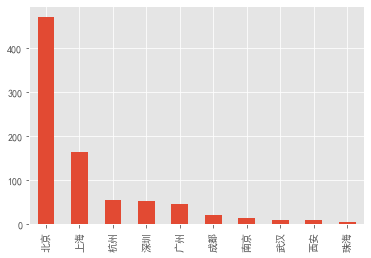

In [33]:
data_clean['city'].value_counts() # 统计各城市的招聘岗位频数
data_clean['city'].value_counts().nlargest(10).plot(kind = 'bar')
# 开头要加rcParams['font.sans-serif'] = ['SimHei']不然显示不出中文

## 处理com_class(统一字符串名称)

In [34]:
list(data['com_class'].unique()) # 用list函数，显示起来更好看些

['公司类型：有限责任公司(台港澳法人独资)',
 '公司类型：股份有限公司(上市)',
 '公司类型：有限责任公司(外国法人独资)',
 nan,
 '公司类型：有限责任公司',
 '公司类型：有限责任公司（法人独资）',
 '公司类型：其他有限责任公司',
 ' ',
 '公司类型：其他股份有限公司(非上市)',
 '公司类型：有限责任公司(中外合资)',
 '公司类型：有限责任公司(自然人投资或控股)',
 '公司类型：有限责任公司(自然人独资)',
 '公司类型：有限责任公司（自然人投资或控股）',
 '公司类型：有限责任公司(法人独资)',
 '公司类型：有限责任公司分公司（自然人独资）',
 '公司类型：股份有限公司(中外合资、上市)',
 '公司类型：有限责任公司（台港澳法人独资）',
 '公司类型：有限责任公司\n',
 '公司类型：有限责任公司（自然人独资）',
 '公司类型：有限责任公司（自然人投资或控股的法人独资）',
 '公司类型：股份有限公司(非上市、自然人投资或控股)',
 '公司类型：有限责任公司(台港澳与境内合资)',
 '公司类型：无',
 '公司类型：股份有限公司分公司(上市、国有控股)',
 '公司类型：私营有限责任公司(自然人控股或私营性质企业控股)',
 '公司类型：全民所有制',
 '公司类型：有限责任公司（外国法人独资）',
 '公司类型：股份有限公司(非上市)',
 '公司类型：股份有限公司(上市、自然人投资或控股)',
 '公司类型：股份有限公司(台港澳与境内合资、上市)',
 '公司类型：其他股份有限公司(上市)',
 '公司类型：有限责任公司分公司（非自然人投资或控股的法人独资）',
 '公司类型：其他股份有限公司（上市）',
 '公司类型：有限责任公司（非自然人投资或控股的法人独资）',
 '公司类型：股份有限公司',
 '公司类型：非上市股份有限公司',
 '公司类型：分公司',
 '公司类型：股份有限公司（上市、自然人投资或控股）',
 '公司类型：有限合伙',
 '公司类型：外商投资公司分公司',
 '公司类型：有限责任公司(台港澳与外国投资者合资)',
 '公司类型：股份有限公司（非上市）',
 '公司类型：有限责任公司(外商投资企业法人独资)',
 '公司类型：上市股份有限公司',
 '公司类型：股份

可以看到上面的数据比较适合构造函数来mapping

In [35]:
def get_com_type(string):
    if string == None:
        return np.nan
    elif ('非上市' in string) or ('未上市' in string):  
        return '股份有限公司（未上市）'
    elif '股份' in string:
        return '股份有限公司（上市）'
    elif '责任' in string:
        return '有限责任公司'
    elif '外商投资' in string:
        return '外商投资公司'
    elif '有限合伙' in string:
        return '有限合伙企业'
    elif '全民所有' in string:
        return '国有企业'
    else:
        return np.nan
com_class = data['com_class'].str.split("：",expand = True)
sum(com_class[1].isna())
com_class.loc[com_class[1].isna(), 1] = None
com_class['com_class'] = com_class[1].apply(get_com_type)
com_class.sample(5)

,0,1,com_class
46,公司类型,有限责任公司(自然人投资或控股),有限责任公司
197,公司类型,有限责任公司(外国法人独资),有限责任公司
854,公司类型,有限责任公司(外国法人独资),有限责任公司
940,公司类型,有限责任公司,有限责任公司
348,公司类型,有限责任公司(自然人投资或控股),有限责任公司


In [36]:
data_clean['com_class'] = com_class['com_class']
data_clean.sample(5)

,auth_capital,city,com_class,com_fullname,com_intro,com_location,com_logo,com_name,day_per_week,est_date,...,job_deadline,job_links,job_title,num_employee,released_time,tag,time_span,update_time,wage,average_wage
213,47175.0,北京,有限责任公司,作业帮教育科技（北京）有限公司,互联网在线教育,北京市海淀区西二旗开拓路1号汇苑开拓大厦A座4层,https://sxsimg.xiaoyuanzhao.com/E5/85/E5824413...,作业帮,4,2015-01-01,...,2018-10-30,https://www.shixiseng.com/intern/inn_uxoebgtxgmg6,算法/数据挖掘实习生,中型企业,acceptable,其他类型,12,2018-02-27 14:41:23,200-300/天,250.0
946,NaN,上海,有限责任公司,北京爱奇艺科技有限公司上海分公司,中国视频行业领先者,上海市长宁区临虹路365号中关村虹桥创新中心北区9座爱奇艺创新大厦,https://sxsimg.xiaoyuanzhao.com/A6/59/A6119AB0...,爱奇艺,5,NaT,...,2018-05-15,https://www.shixiseng.com/intern/inn_ekpm74odjheg,算法实习生,大型企业,old,算法,7,2018-01-16 18:12:59,200-220/天,210.0
933,66045.0,北京,有限责任公司,新浪网技术（中国）有限公司,中国最大的社会化媒体平台,北京市海淀区西北旺东路新浪总部大厦,https://sxsimg.xiaoyuanzhao.com/84/56/84C74A31...,新浪微博,5,2004-01-01,...,2018-03-25,https://www.shixiseng.com/intern/inn_t5rfgugjpyxp,算法工程师,大型企业,old,算法,3,2018-01-26 17:53:39,70-119/天,94.5
722,1000.0,上海,有限责任公司,上海英恒电子有限公司,专注于汽车电子应用市场元器件销售与技术开发服务,张衡路1000弄68号,https://sxsimg.xiaoyuanzhao.com/2E/29/2ECE198C...,英恒电子,5,2001-01-01,...,2018-03-30,https://www.shixiseng.com/intern/inn_5njtpoyo8oyv,电机控制算法工程师（上海）,中型企业,new,半导体/芯片,3,2018-03-16 09:37:12,80-100/天,90.0
482,3000.0,北京,有限责任公司,中科博宏（北京）科技有限公司,引领金融、商业、交通、安防、互联网+等模块需求应用，铸就行业ONLY.1,北京市安定路33号化信大厦A座1102室,https://sxsimg.xiaoyuanzhao.com/9C/BB/9C811967...,中科博宏,4,2017-01-01,...,2018-08-01,https://www.shixiseng.com/intern/inn_wbwkms6swjgx,算法SDK优化工程师实习生,小型企业,newest,算法,6,2018-03-21 13:41:44,150-300/天,225.0


调整下列的顺序

In [37]:
data_clean = data_clean.reindex(columns = ['com_fullname', 'com_name', 'job_academic', 'job_links', 
                                         'tag','auth_capital', 'day_per_week', 'num_employee', 'time_span',
                                         'average_wage', 'est_date', 'job_deadline', 'released_time',
                                         'update_time', 'city', 'com_class', 'com_intro', 'job_title',
                                         'com_logo', 'industry'])
# reindex函数 ：pd.DataFrame.reindex(columns = [col1, col2, ..., coln])
data_clean.to_csv('./data_clean.csv',index = False, encoding = 'utf_8_sig')
# 需要加上encoding  = 'utf_8_sig'，这样才能不乱码

# 数据分析

## 查看数据基本情况

In [38]:
data_clean.sample(3)

,com_fullname,com_name,job_academic,job_links,tag,auth_capital,day_per_week,num_employee,time_span,average_wage,est_date,job_deadline,released_time,update_time,city,com_class,com_intro,job_title,com_logo,industry
432,广州众聚智能科技有限公司,众聚智能,不限,https://www.shixiseng.com/intern/inn_4fyzedmihrln,算法,200.0,3,小型企业,3,90.0,2017-01-01,2018-05-31,newest,2018-03-21 16:57:18,广州,有限责任公司,现开展的项目包括：智能出行、智能洗车、智能售货等。,信息采集员,https://sxsimg.xiaoyuanzhao.com/37/B5/37003139...,计算机/互联网
767,广州市讯码通讯科技有限公司,讯码科技,硕士,https://www.shixiseng.com/intern/inn_biugppocfws0,Python,550.0,3,小型企业,9,300.0,2007-01-01,2018-03-23,acceptable,2018-03-14 14:32:51,广州,有限责任公司,致力于互联网电视整体方案的研发,图像识别算法实习生,https://sxsimg.xiaoyuanzhao.com/FF/2E/FF614D2F...,NaN
130,博彦科技股份有限公司,博彦科技,硕士,https://www.shixiseng.com/intern/inn_eqmmw5cvdeua,数据挖掘,16763.0,5,大型企业,8,300.0,1995-01-01,2018-03-30,new,2018-03-16 17:20:01,北京,股份有限公司（上市）,亚洲领先的全方位IT咨询、服务及行业解决方案提供商,数据挖掘分析实习生,https://sxsimg.xiaoyuanzhao.com/2C/C6/2CB6BD95...,"企业服务,互联网"


In [39]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 878 entries, 0 to 977
Data columns (total 20 columns):
com_fullname     874 non-null object
com_name         874 non-null object
job_academic     878 non-null object
job_links        878 non-null object
tag              878 non-null object
auth_capital     782 non-null float64
day_per_week     878 non-null int64
num_employee     872 non-null object
time_span        878 non-null int64
average_wage     878 non-null float64
est_date         788 non-null datetime64[ns]
job_deadline     878 non-null datetime64[ns]
released_time    878 non-null object
update_time      878 non-null datetime64[ns]
city             874 non-null object
com_class        794 non-null object
com_intro        874 non-null object
job_title        878 non-null object
com_logo         874 non-null object
industry         862 non-null object
dtypes: datetime64[ns](3), float64(2), int64(2), object(13)
memory usage: 184.0+ KB


## 查看城市与职位数量

Text(0, 0.5, '数量')

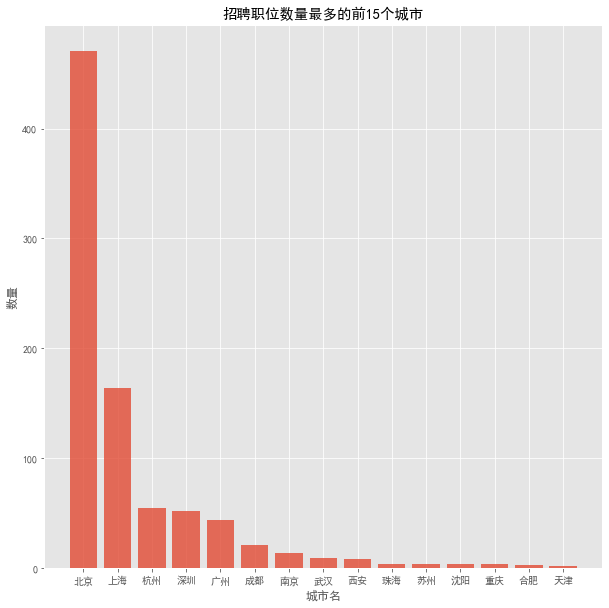

In [65]:
city = data_clean['city'].value_counts().nlargest(15)
# 用pyecharts画图
dir(pyecharts.charts)   # 用dir函数查看模块内函数和参数等
# help(pyecharts.charts)  # 查看函数内容
# bar = pyecharts.Bar('城市与职位数量')
# bar.add('', city.index, city.values, mark_point['max'])
plt.bar(city.index, city.values, alpha = .8)
plt.title('招聘职位数量最多的前15个城市')
plt.xlabel('城市名')
plt.ylabel('数量')


查看占比(用format函数格式化数值成想要的格式)

In [75]:
city_pct = (city/city.sum()).map(lambda x: '{:,.2%}'.format(x))
city_pct[:15]


北京    54.83%
上海    19.09%
杭州     6.40%
深圳     6.05%
广州     5.12%
成都     2.44%
南京     1.63%
武汉     1.05%
西安     0.93%
珠海     0.47%
苏州     0.47%
沈阳     0.47%
重庆     0.47%
合肥     0.35%
天津     0.23%
Name: city, dtype: object

## 查看前5个城市的总占比

In [77]:
(city/city.sum())[:5].sum()

0.9150174621653084

## 查看某个城市的招聘岗位的公司的招聘数

In [82]:
data_clean.loc[data_clean['city'] == '杭州', 'com_name'].value_counts()[:5]
# 用value_count()得出每个公司招聘数的频数


非白三维    10
光珀       6
虹软       5
同花顺      4
菜鸟网络     3
Name: com_name, dtype: int64

## 查看前15个城市中招聘岗位数前5的公司

构造一个函数，返回招聘数前5的公司

In [84]:
def topN(dataframe, n = 5):
    return dataframe.value_counts()[:n]

用groupby()函数将数据集根据城市分割成几部分

In [88]:
data_clean.groupby('city').com_name.apply(topN).loc[list(city_pct[:15].index)]


city               
上海    华院数据             10
      爱奇艺               8
      驭势科技              7
      麦穗人工智能            4
      纵目科技              4
北京    百度               21
      滴滴出行             19
      今日头条             12
      京东金融             10
      作业帮               9
南京    金智信息              2
      南京地平线机器人技术        2
      小黑鱼科技             2
      途牛旅游网             1
      矽岸信息              1
合肥    乐职网               3
天津    数能科技              1
      天瞳威视              1
广州    网易游戏              5
      探迹                4
      唯品会               2
      虎牙信息              2
      佰聆数据              2
成都    天佑飞天              3
      知道创宇              2
      风雷体育              1
      准星云学              1
      果小美               1
杭州    非白三维             10
      光珀                6
      虹软                5
      同花顺               4
      菜鸟网络              3
武汉    小弦科技              2
      光庭信息              1
      武汉安天              1
      mindsee           1
      微模式         

## 查看平均薪资

In [91]:
data_clean['salary'] = data_clean['average_wage'] * data_clean['day_per_week']*4
data_clean['salary'].mean()

3644.9407744874716

## 观察城市与薪资的关系

In [94]:
salary_by_city = data_clean.groupby('city')['salary'].mean()
salary_by_city.nlargest(10)

city
晋江    9000.000000
长沙    4500.000000
东莞    4150.000000
杭州    4139.345455
福州    4000.000000
北京    3789.927813
深圳    3783.538462
苏州    3775.000000
厦门    3750.000000
上海    3579.170732
Name: salary, dtype: float64

In [99]:
top10_city = salary_by_city[city_pct.index[:10]].sort_values(ascending = False)
top10_city
salary_by_city[['上海','深圳']]

city
上海    3579.170732
深圳    3783.538462
Name: salary, dtype: float64

画出北上广深等城市的平均实习工资

Text(0.5, 0, '城市')

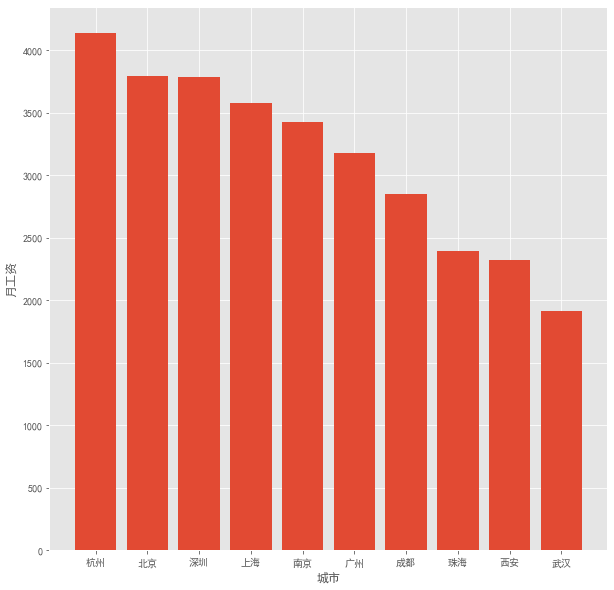

In [104]:
plt.bar(top10_city.index[:10], top10_city.values[:10])
plt.ylabel('月工资')
plt.xlabel('城市')

再看这10个城市的实习工资分布

D:\Anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:211: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0.0, flags=flags)
D:\Anaconda\lib\site-packages\matplotlib\backends\backend_agg.py:180: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0, flags=flags)


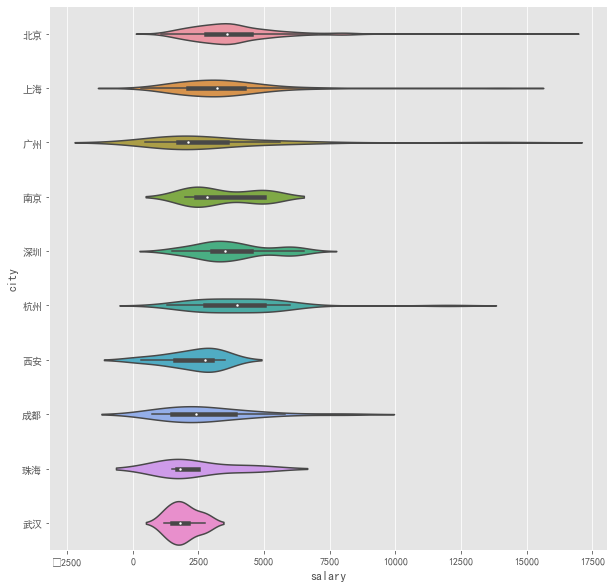

In [118]:
top10_city_box = data_clean.loc[data_clean['city'].isin(top10_city.index)]
sns.violinplot(x = 'salary', y = 'city', data = top10_city_box)

## 岗位的学位要求

Text(0, 0.5, '数量')

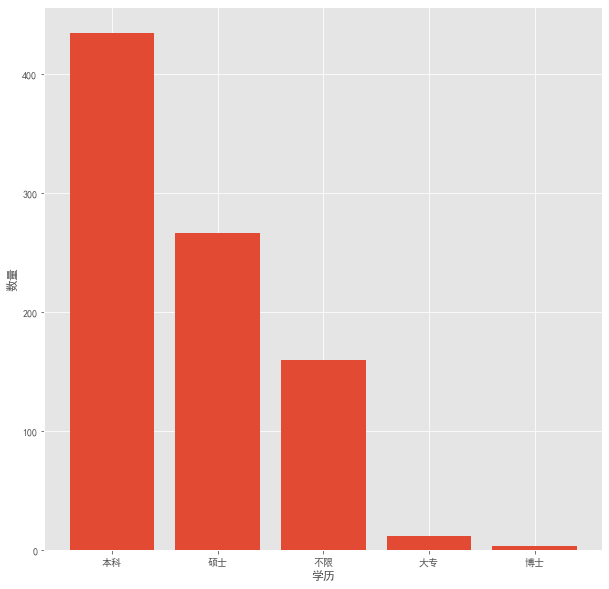

In [127]:
job_academic = data_clean['job_academic'].value_counts()
job_academic
plt.figure()
plt.bar(job_academic.index, job_academic.values)
plt.xlabel('学历')
plt.ylabel('数量')


## 学历和工资的关系

In [129]:
data_clean.groupby(['job_academic'])['salary'].mean().sort_values()

job_academic
大专    2165.000000
不限    3570.525000
本科    3622.266667
硕士    3786.546816
博士    4075.000000
Name: salary, dtype: float64

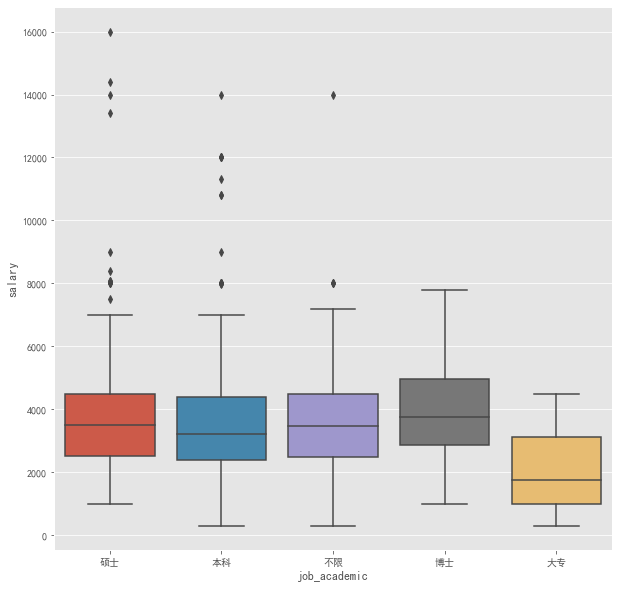

In [130]:
sns.boxplot(x = 'job_academic', y = 'salary', data = data_clean)

## 行业和岗位等的关系

In [131]:
data_clean['industry'].sample(5)

470    计算机/互联网,通信
520       计算机/互联网
571       计算机/互联网
80            互联网
503          人工智能
Name: industry, dtype: object

难点来了。这里需要用pd.value_counts()求出每列中每个行业的招聘数目，再用sum(axis = 1)累积每一列的值，得到总数

In [138]:
industry = data_clean.industry.str.split('/|，', expand = True)
# industry.apply(pd.value_counts)
industry_top15 = industry.apply(pd.value_counts).sum(axis = 1).nlargest(15)


Text(0, 0.5, '招聘数目')

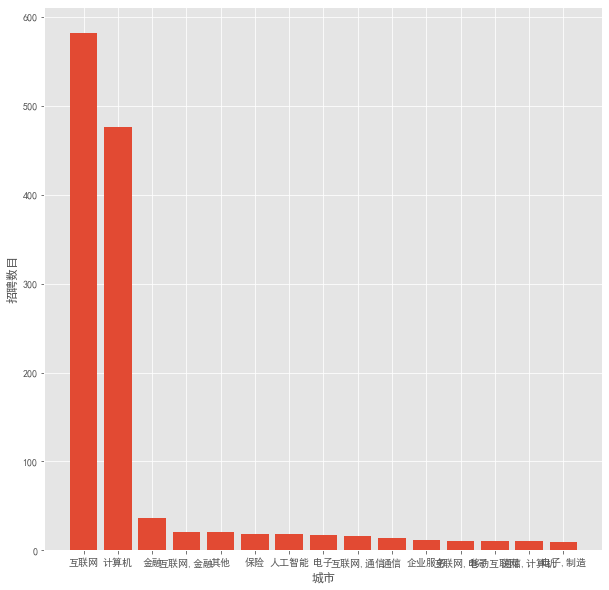

In [140]:
plt.bar(industry_top15.index, industry_top15.values)
plt.xlabel('城市')
plt.ylabel('招聘数目')

## 查看公司与职位数量、实习月薪的关系

In [143]:
data_clean.groupby('com_name').salary.agg(['count', 'mean']).sort_values(by = 'count', ascending = False)
# 留意agg()函数的用法:。。。只能意会不能言传
# data_clean.groupby('com_name')['salary'].mean().sort_values(ascending = False)

,count,mean
com_name,,
百度,21,3256.190476
滴滴出行,19,3614.736842
中科龙智,13,3000.000000
爱奇艺,12,3983.166667
今日头条,12,6400.500000
...,...,...
小多科技,1,2400.000000
寻球科技,1,4000.000000
寰宇声望,1,5000.000000


## 公司规模与职位数量

In [144]:
data_clean.groupby('num_employee')['salary'].mean()

num_employee
中型企业    3633.823322
大型企业    3497.136752
小型企业    3748.304225
Name: salary, dtype: float64

## 公司实习期长度

In [147]:
data_clean['time_span'].value_counts()

3     289
6     190
4     113
7      73
5      67
8      35
10     34
13     20
12     17
9      11
11      8
15      6
16      4
14      4
2       3
18      2
17      1
1       1
Name: time_span, dtype: int64

In [148]:
data_clean['time_span'].mean()

5.519362186788155

## 企业成立时间

+ 首先，因为计算的是企业的数量而不是职位的数量，所以要先drop掉重复的企业
+ 接着，把之前清理好的成立时间数据，再清理一下，以年做单位
+ 然后，以年分组计算数量，便得到每年新成立的公司数量
+ 发现：从2013年开始，公司呈现爆发式增长

In [152]:
# 用drop_duplicates(subsets)函数drop掉同样的公司
est_date = data_clean.drop_duplicates(subset = 'com_name')

In [165]:
# 转换时间单位：以年为单位
import warnings
warnings.filterwarnings('ignore')
est_date['est_year'] = pd.DatetimeIndex(est_date['est_date']).year
# pd.DatetimeIndex(est_date['est_date'])
# est_date['est_date']
num_com_by_year = est_date.groupby('est_year')['com_name'].count()
num_com_by_year

est_year
1980.0     1
1990.0     1
1991.0     1
1992.0     3
1993.0     1
1994.0     6
1995.0     5
1996.0     2
1997.0     2
1998.0     3
1999.0     4
2000.0     9
2001.0     6
2002.0     4
2003.0     7
2004.0     7
2005.0     7
2006.0    14
2007.0    14
2008.0    18
2009.0    19
2010.0    12
2011.0    20
2012.0    15
2013.0    29
2014.0    47
2015.0    57
2016.0    57
2017.0    42
2018.0     2
Name: com_name, dtype: int64

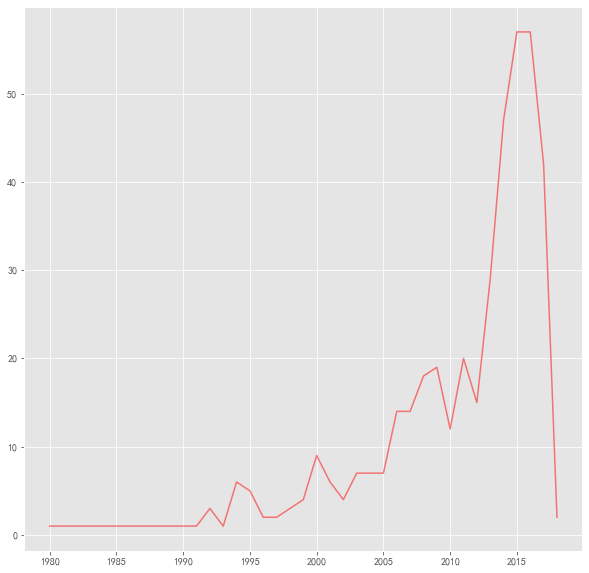

In [170]:
plt.plot(num_com_by_year.index, num_com_by_year.values, 'r', alpha = .5)

## 查看新成立的公司的公司规模

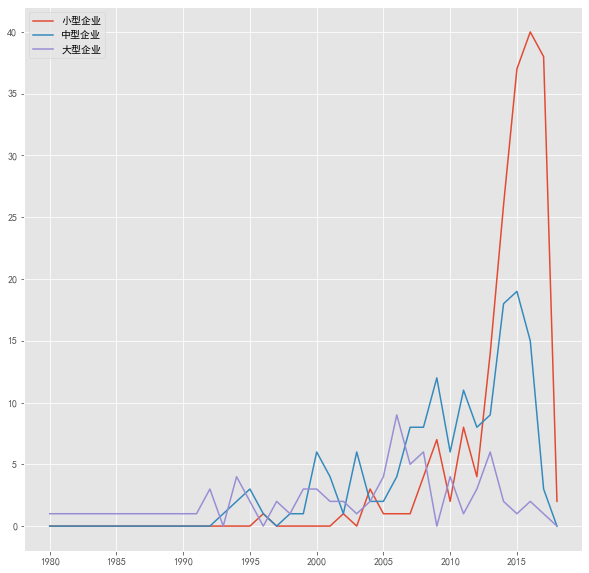

In [178]:

scale_VS_year = est_date.groupby(['num_employee', 'est_year'])['com_name'].count()
scale_VS_year_s = scale_VS_year['小型企业'].reindex(num_com_by_year.index, fill_value=0)
scale_VS_year_m = scale_VS_year['中型企业'].reindex(num_com_by_year.index, fill_value=0)
scale_VS_year_l = scale_VS_year['大型企业'].reindex(num_com_by_year.index, fill_value=0)

plt.plot(scale_VS_year_s.index, scale_VS_year_s.values)
plt.plot(scale_VS_year_m.index, scale_VS_year_m.values)
plt.plot(scale_VS_year_l.index, scale_VS_year_l.values)
plt.legend(['小型企业','中型企业','大型企业'])